In [37]:
import numpy as np
import torch 
import gymnasium as gym
import matplotlib.pyplot as plt
import dill

from copy import deepcopy
from tqdm import tqdm
from four_room.env import FourRoomsEnv
from four_room.wrappers import gym_wrapper, gym_wrapper_state
from four_room.constants import state_to_q, state_to_q_np
from rnd_exploration.dataset import State
from four_room.constants import train_config, val_config, test_config, size
from uvu.uvu import UVU
from dqn.model import DQN
from utils.episode import LastEpisode
from utils.record_scores import record_uvu_scores, record_dqn_scores
from four_room.utils import obs_to_state, obs_to_img, reverse_doors
from four_room.shortest_path import find_all_action_values

gym.register('MiniGrid-FourRooms-v1', FourRoomsEnv)


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/home/aryan/Documents/Uni/rnd_dqn_four_room/.venv/lib/python3.13/site-packages/gymnasium/envs/registration.py:694: UserWarning: WARN: Overriding environment MiniGrid-FourRooms-v1 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


In [3]:
env = gym_wrapper_state(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        use_cnn=True
    )
    
val_env = gym_wrapper_state(gym.make(
        'MiniGrid-FourRooms-v1', 
        agent_pos= train_config['agent positions'],
        goal_pos = train_config['goal positions'],
        doors_pos = train_config['topologies'],
        agent_dir = train_config['agent directions'],
        size=size
    ),
)

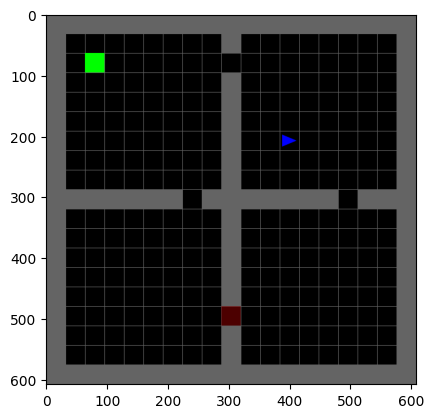

In [35]:
coord = (9, 15)
highlight_mask = np.zeros((19, 19), dtype=np.bool_)
highlight_mask[coord[0], coord[1]] = True
ep_colors = np.empty_like(highlight_mask, dtype=object)
ep_colors[coord[0], coord[1]] = (152, 0, 0)
img = env.unwrapped.render(highlight_mask=highlight_mask, colors=ep_colors, agent_col=(0, 0, 255))
plt.imshow(img)


In [4]:
obs, _ = env.reset()

In [25]:
obs2, _ = env.reset()

In [32]:
agent = UVU(
    env=env,
    val_env=val_env,
    capacity=1000,
    tau=0.01,
    lr=3e-4,
    boostrap_prob=1.0,
    device='cuda',
    use_cnn=True,
    use_action=True, 
    use_dual=False, 
    use_norm=False, 
    hidden_layers=[512, 512, 512],
    hidden_layers_g=[512, 512, 512],
    init_func='orthogonal',
    scale=1, 
    num_heads=512,
)

action = torch.randint(0, 3, (1, 1)).to('cuda')
# agent.epistemic(torch.from_numpy(obs).unsqueeze(dim=0).to('cuda').float(), action)
agent.epistemic(agent.get_obs(obs), action), agent.epistemic_no_act(agent.get_obs(obs)) 


using DQNBaseAction
using DQNBaseAction


(tensor([[13.3480]], device='cuda:0'),
 tensor([[13.3480, 13.3544, 13.3671]], device='cuda:0'))

using DQNBaseAction
using DQNBaseAction


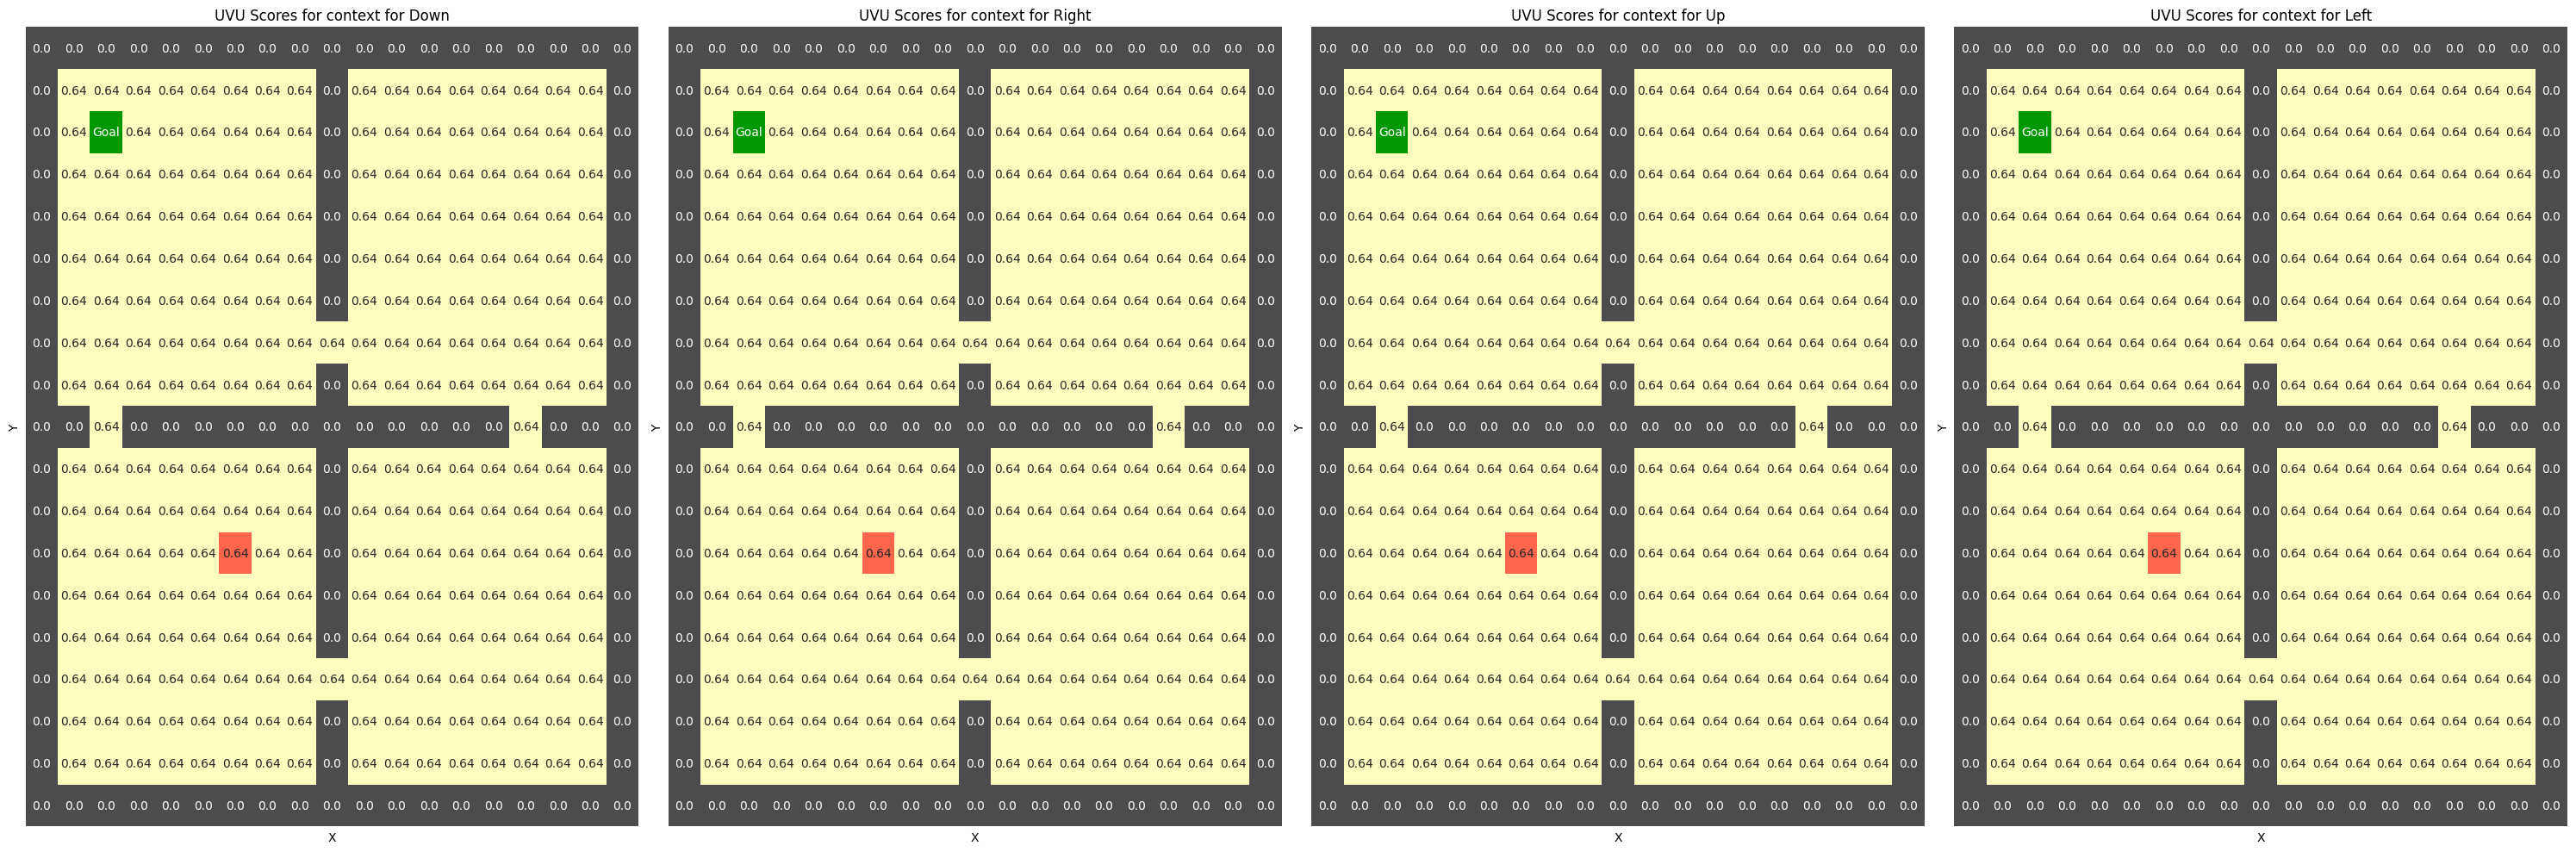

In [ ]:
from plot_interactive import find_states, plot_env_heatmap

agent = UVU(
    env=env,
    val_env=val_env,
    capacity=1000,
    tau=0.1,
    lr=3e-4,
    boostrap_prob=1.0,
    device='cuda',
    use_cnn=True,
    use_action=True, 
    use_dual=False, 
    use_norm=False, 
    hidden_layers=[512, 512, 512],
    hidden_layers_g=[512, 512, 512],
    init_func='orthogonal',
    scale=1, 
    num_heads=512,
)

# agent = DQN(
#     env=env,
#     val_env=val_env,
#     capacity=1000,
#     tau=0.001,
#     lr=3e-4,
#     device='cuda',
#     use_cnn=True,
#     cnn_features=1024,
#     hidden_layers=[1024, 2048, 1024],
#     residual=True
# )

fig, axes = plt.subplots(1, 4, figsize=(30, 10))
context = 0
_, _, uvu_scores = record_uvu_scores(agent, context, 0, render=True, use_cnn=True)
uvu_scores = uvu_scores 
env.get_wrapper_attr('set_context')(context)
obs, _ = env.reset()
context_info = env.get_wrapper_attr('context_info')(context)
context_info = (*context_info, env.get_wrapper_attr('valid_pos'))
agent_pos = env.get_wrapper_attr('agent_pos')

plot_env_heatmap(
    uvu_scores[0].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Down',
    axes[0],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[1].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Right',
    axes[1],
    agent_pos=agent_pos,
    intize=False,
)

plot_env_heatmap(
    uvu_scores[2].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Up',
    axes[2],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[3].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Left',
    axes[3],
    agent_pos=agent_pos,
    intize=False
)


plt.tight_layout() 


In [35]:
def get_state(obs, use_cnn):
    if use_cnn:
        return obs_to_state(obs)
    else:
        first = [int(item) for item in obs[:5]]
        return tuple(first + list(reverse_doors(obs)))

In [39]:
env = gym_wrapper_state(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        use_cnn=True
    )

done = False
context = 0
env.get_wrapper_attr('set_context')(context)
obs, _ = env.reset()
for step in tqdm(range(1, 1000)):
    state = get_state(obs, use_cnn=True)
    q = state_to_q_np[context, state[0], state[1], state[2]]
    action = q.argmax() if isinstance(q, np.ndarray) else np.array(q).argmax()
    
    obs_prime, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    state_next = get_state(obs_prime, use_cnn=True)
    q_next = state_to_q_np[context, state_next[0], state_next[1], state_next[2]]
    next_action = q_next.argmax()
        
    agent.buffer.update(obs, action, reward, obs_prime, next_action, int(done), q_value=q)
    obs = obs_prime
    
    if agent.buffer.size > 128:
        agent.update_step(128)
        agent.soft_update()
    

100%|██████████| 999/999 [00:13<00:00, 75.39it/s] 


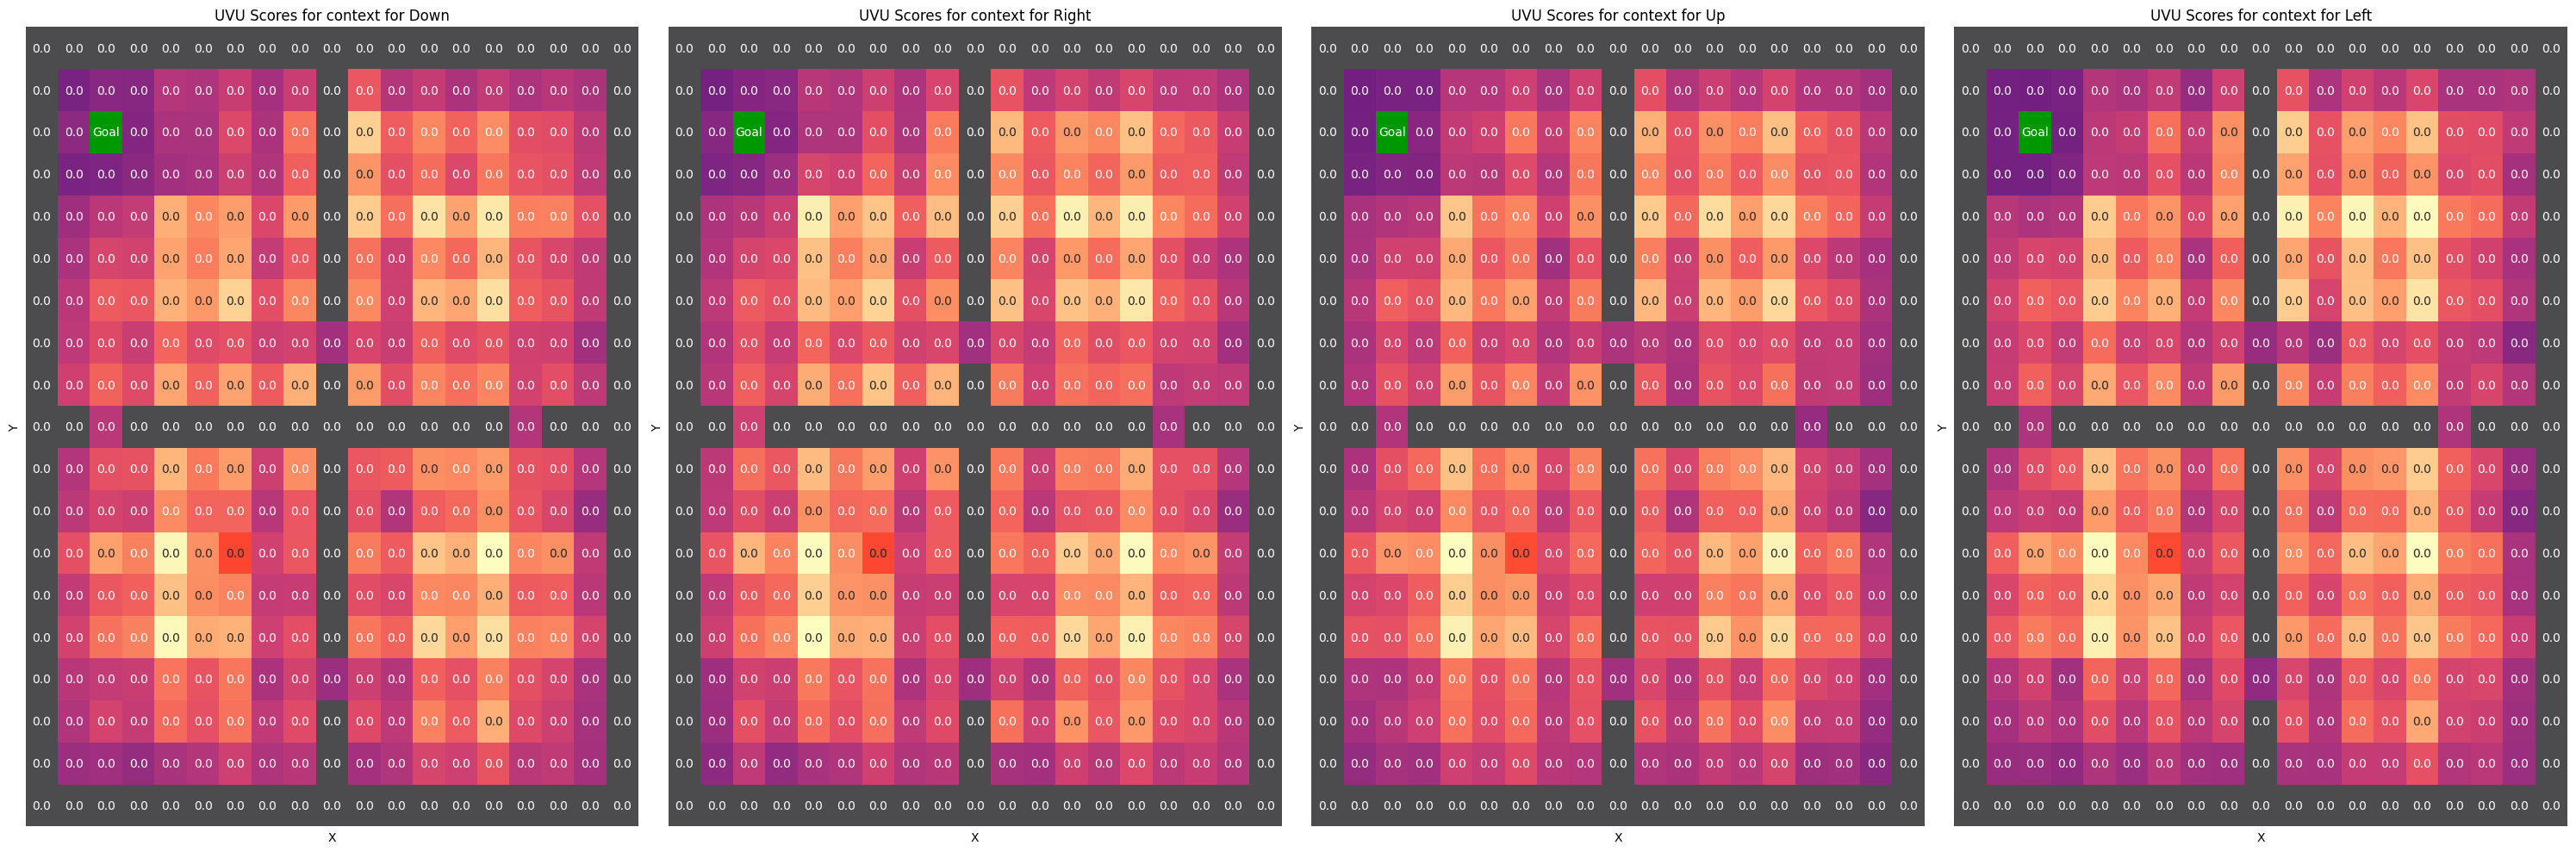

In [40]:
from plot_interactive import find_states, plot_env_heatmap

fig, axes = plt.subplots(1, 4, figsize=(30, 10))
context = 0
_, _, uvu_scores = record_uvu_scores(agent, context, 0, use_cnn=True)
uvu_scores = uvu_scores 
env.get_wrapper_attr('set_context')(context)
obs, _ = env.reset()
context_info = env.get_wrapper_attr('context_info')(context)
context_info = (*context_info, env.get_wrapper_attr('valid_pos'))
agent_pos = env.get_wrapper_attr('agent_pos')

plot_env_heatmap(
    uvu_scores[0].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Down',
    axes[0],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[1].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Right',
    axes[1],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[2].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Up',
    axes[2],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[3].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Left',
    axes[3],
    agent_pos=agent_pos,
    intize=False
)


plt.tight_layout() 


In [52]:
# buffer = agent.buffer
agent = UVU(
    env=env,
    val_env=val_env,
    capacity=1000,
    tau=0.01,
    lr=3e-4,
    device='cuda',
    use_cnn=False,
    cnn_features=512,
    hidden_layers=[512, 512, 512],
    hidden_layers_g=[512, 512, 512],
    residual=True,
    init='kaiming',
    num_heads=512,
    use_state=True,
    stack_linear=False
)
agent.buffer = buffer

In [10]:
a = torch.randn((16, 10, 1))
b = torch.randn_like(a)
mask = torch.randint(0, 2, (16, 10))

In [11]:
a, b, mask

(tensor([[[-0.4109],
          [ 0.2161],
          [-0.8533],
          [ 0.2332],
          [-0.2680],
          [-0.2504],
          [ 0.9485],
          [ 0.3954],
          [ 0.3707],
          [-0.5288]],
 
         [[-1.2828],
          [ 0.5552],
          [-2.2982],
          [-0.7814],
          [-0.4655],
          [-0.9256],
          [-1.4000],
          [-0.0806],
          [ 0.8400],
          [-0.7138]],
 
         [[ 0.8390],
          [-0.2038],
          [ 0.0893],
          [ 0.7638],
          [ 2.1587],
          [ 0.3887],
          [ 1.1120],
          [-0.4670],
          [ 2.4811],
          [-0.1862]],
 
         [[-0.4679],
          [ 0.0462],
          [ 0.0896],
          [ 0.7526],
          [ 1.8053],
          [ 0.2550],
          [-0.7795],
          [ 0.7687],
          [-0.6931],
          [-1.6032]],
 
         [[-0.6277],
          [ 0.6090],
          [ 0.2737],
          [-0.6931],
          [-0.6320],
          [ 1.4789],
          [-1.3440],
 

False

In [53]:
agent.update_step(128)

torch.Size([128, 512, 1]) torch.Size([128, 512]) torch.Size([128, 512, 1]) torch.Size([128, 512])
